In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# historical FCF
fcf_historical = pd.Series({
    2023: 6313.0,
    2024: 9498.0,
    2025: 12434.0,
    2026: 14402.0,
})

# projected FCF
fcf_proj = pd.Series({
    2027: 15841.8,
    2028: 17385.7,
    2029: 18830.0,
    2030: 20184.9,
    2031: 21355.7,
})

# valuation outputs
wacc = 0.0897
implied_price = 344.67
current_price = 183.26
terminal_growth_rate = 0.025

print("Data loaded, ready to visualise")


Data loaded, ready to visualise


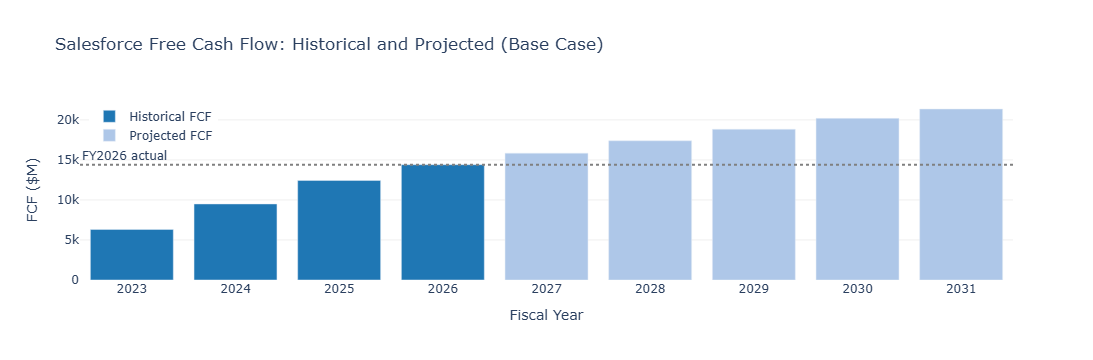

In [2]:
# FCF bridge: historical actuals vs projections
fig1 = go.Figure()

# historical bars
fig1.add_trace(go.Bar(
    x=list(fcf_historical.index),
    y=list(fcf_historical.values),
    name='Historical FCF',
    marker_color='#1f77b4',
))

# projected bars
fig1.add_trace(go.Bar(
    x=list(fcf_proj.index),
    y=list(fcf_proj.values),
    name='Projected FCF',
    marker_color='#aec7e8',
))

# current price reference line
fig1.add_hline(
    y=14402,
    line_dash='dot',
    line_color='gray',
    annotation_text='FY2026 actual',
    annotation_position='top left'
)

fig1.update_layout(
    title='Salesforce Free Cash Flow: Historical and Projected (Base Case)',
    xaxis_title='Fiscal Year',
    yaxis_title='FCF ($M)',
    legend=dict(x=0.01, y=0.99),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#f0f0f0'),
    bargap=0.2,
)

fig1.show()


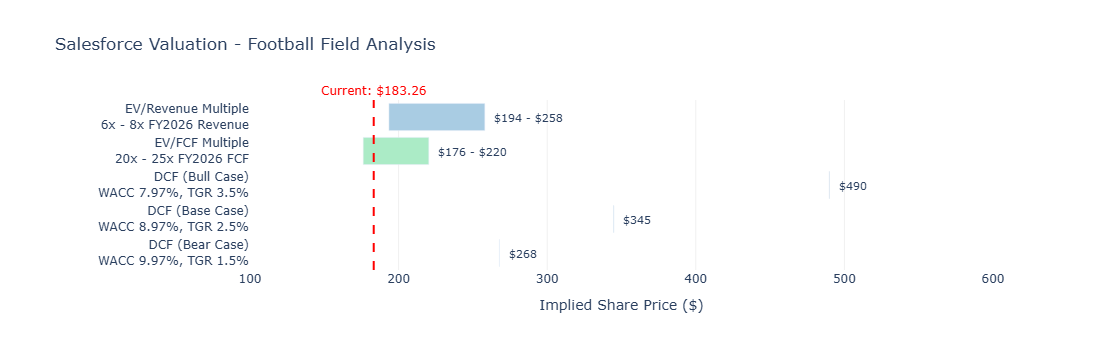

In [3]:
# football field chart - valuation range across methodologies
methodologies = [
    'DCF (Bear Case)<br>WACC 9.97%, TGR 1.5%',
    'DCF (Base Case)<br>WACC 8.97%, TGR 2.5%',
    'DCF (Bull Case)<br>WACC 7.97%, TGR 3.5%',
    'EV/FCF Multiple<br>20x - 25x FY2026 FCF',
    'EV/Revenue Multiple<br>6x - 8x FY2026 Revenue',
]

# low and high for each methodology
low_values =  [267.8, 344.7, 489.8, 176.2, 193.5]
high_values = [267.8, 344.7, 489.8, 220.3, 258.0]

# for DCF scenarios show as points not ranges
# for multiples show as ranges
fig2 = go.Figure()

colors = ['#d4e6f1', '#2980b9', '#1a5276', '#abebc6', '#a9cce3']

for i, (method, low, high) in enumerate(zip(methodologies, low_values, high_values)):
    fig2.add_trace(go.Bar(
        name=method,
        y=[method],
        x=[high - low if high != low else 0.1],
        base=low,
        orientation='h',
        marker_color=colors[i],
        showlegend=False,
    ))
    # add value labels
    fig2.add_annotation(
        x=high + 5,
        y=method,
        text=f"${low:.0f}" if low == high else f"${low:.0f} - ${high:.0f}",
        showarrow=False,
        font=dict(size=11),
        xanchor='left',
    )

# current price line
fig2.add_vline(
    x=current_price,
    line_dash='dash',
    line_color='red',
    line_width=2,
    annotation_text=f'Current: ${current_price}',
    annotation_position='top',
    annotation_font_color='red',
)

fig2.update_layout(
    title='Salesforce Valuation - Football Field Analysis',
    xaxis_title='Implied Share Price ($)',
    xaxis=dict(range=[100, 600]),
    plot_bgcolor='white',
    xaxis_gridcolor='#f0f0f0',
    height=350,
    margin=dict(l=250, r=100),
)

fig2.show()

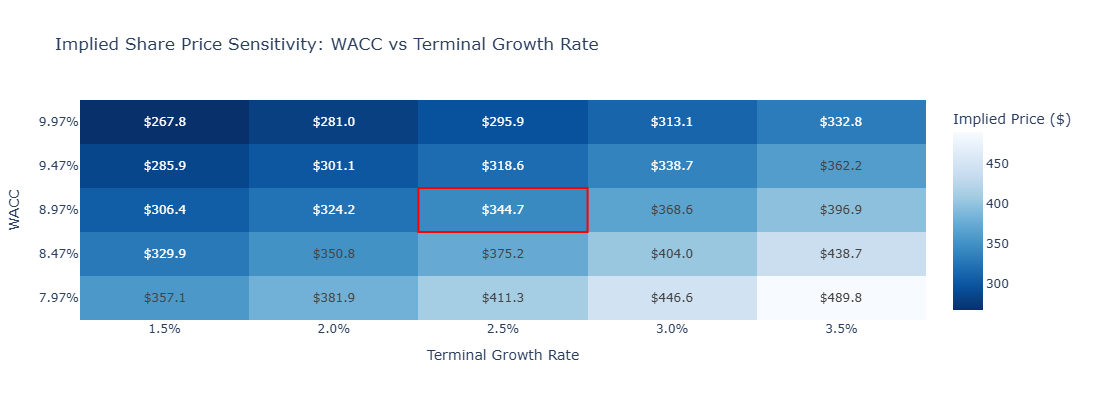

In [4]:
import plotly.graph_objects as go

# sensitivity data
wacc_range = [0.0797, 0.0847, 0.0897, 0.0947, 0.0997]
tgr_range  = [0.015, 0.020, 0.025, 0.030, 0.035]

prices = [
    [357.1, 381.9, 411.3, 446.6, 489.8],
    [329.9, 350.8, 375.2, 404.0, 438.7],
    [306.4, 324.2, 344.7, 368.6, 396.9],
    [285.9, 301.1, 318.6, 338.7, 362.2],
    [267.8, 281.0, 295.9, 313.1, 332.8],
]

# text labels for each cell
text = [[f"${v}" for v in row] for row in prices]

fig3 = go.Figure(data=go.Heatmap(
    z=prices,
    x=[f"{g:.1%}" for g in tgr_range],
    y=[f"{w:.2%}" for w in wacc_range],
    text=text,
    texttemplate="%{text}",
    textfont=dict(size=12),
    colorscale='Blues',
    reversescale=True,
    showscale=True,
    colorbar=dict(title='Implied Price ($)'),
))

# mark current price cell (closest to base case)
fig3.add_shape(
    type='rect',
    x0=1.5, x1=2.5,
    y0=1.5, y1=2.5,
    line=dict(color='red', width=2),
)

fig3.update_layout(
    title='Implied Share Price Sensitivity: WACC vs Terminal Growth Rate',
    xaxis_title='Terminal Growth Rate',
    yaxis_title='WACC',
    height=400,
)

fig3.show()